In [3]:
!pip install caer

  Using cached caer-2.1.1-py3-none-any.whl.metadata (8.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 8.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 80.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.1/513.1 kB 34.1 MB/s eta 0:00:00


In [4]:
!pip install caer[canaro]

In [7]:
import os
import caer
import numpy as np
import cv2 as cv
import gc

In [9]:
IMAGE_SIZE = (80,80)
channels = 1
char_path = r'/kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/simpsons_dataset'

In [15]:
char_dict = {}
for char in os.listdir(char_path):
    char_dict[char] = len(os.listdir(os.path.join(char_path, char)))

# sort in descending order
char_dict = caer.sort_dict(char_dict, descending =True)
char_dict

[('homer_simpson', 2246),
 ('ned_flanders', 1454),
 ('moe_szyslak', 1452),
 ('lisa_simpson', 1354),
 ('bart_simpson', 1342),
 ('marge_simpson', 1291),
 ('krusty_the_clown', 1206),
 ('principal_skinner', 1194),
 ('charles_montgomery_burns', 1193),
 ('milhouse_van_houten', 1079),
 ('chief_wiggum', 986),
 ('abraham_grampa_simpson', 913),
 ('sideshow_bob', 877),
 ('apu_nahasapeemapetilon', 623),
 ('kent_brockman', 498),
 ('comic_book_guy', 469),
 ('edna_krabappel', 457),
 ('nelson_muntz', 358),
 ('lenny_leonard', 310),
 ('mayor_quimby', 246),
 ('waylon_smithers', 181),
 ('maggie_simpson', 128),
 ('groundskeeper_willie', 121),
 ('barney_gumble', 106),
 ('selma_bouvier', 103),
 ('carl_carlson', 98),
 ('ralph_wiggum', 89),
 ('patty_bouvier', 72),
 ('martin_prince', 71),
 ('professor_john_frink', 65),
 ('snake_jailbird', 55),
 ('cletus_spuckler', 47),
 ('rainier_wolfcastle', 45),
 ('simpsons_dataset', 42),
 ('agnes_skinner', 42),
 ('sideshow_mel', 40),
 ('otto_mann', 32),
 ('fat_tony', 27),
 (

In [19]:
characters = []
count = 0
for i in char_dict:
    characters.append(i[0])
    count += 1
    if count >= 10 :
        break

characters

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

In [25]:
# creating training data
train = caer.preprocess_from_dir(char_path, characters, channels = channels, IMG_SIZE=IMAGE_SIZE, isShuffle=True)

[INFO] Could not find a file to load from. Generating the training data
----------------------------------------------
[INFO] At 1000 files
[INFO] At 2000 files
[INFO] 2246 files found in 5.508046627044678s
[INFO] At 1000 files
[INFO] 1454 files found in 4.395687818527222s
[INFO] At 1000 files
[INFO] 1452 files found in 4.271552324295044s
[INFO] At 1000 files
[INFO] 1354 files found in 5.7666895389556885s
[INFO] At 1000 files
[INFO] 1342 files found in 4.408876657485962s
[INFO] At 1000 files
[INFO] 1291 files found in 4.071691274642944s
[INFO] At 1000 files
[INFO] 1206 files found in 3.975095748901367s
[INFO] At 1000 files
[INFO] 1194 files found in 4.2773027420043945s
[INFO] At 1000 files
[INFO] 1193 files found in 4.050940275192261s
[INFO] At 1000 files
[INFO] 1079 files found in 3.9360315799713135s
----------------------------------------------
[INFO] 13811 files preprocessed! Took 2m 56s


In [26]:
len(train)

13811

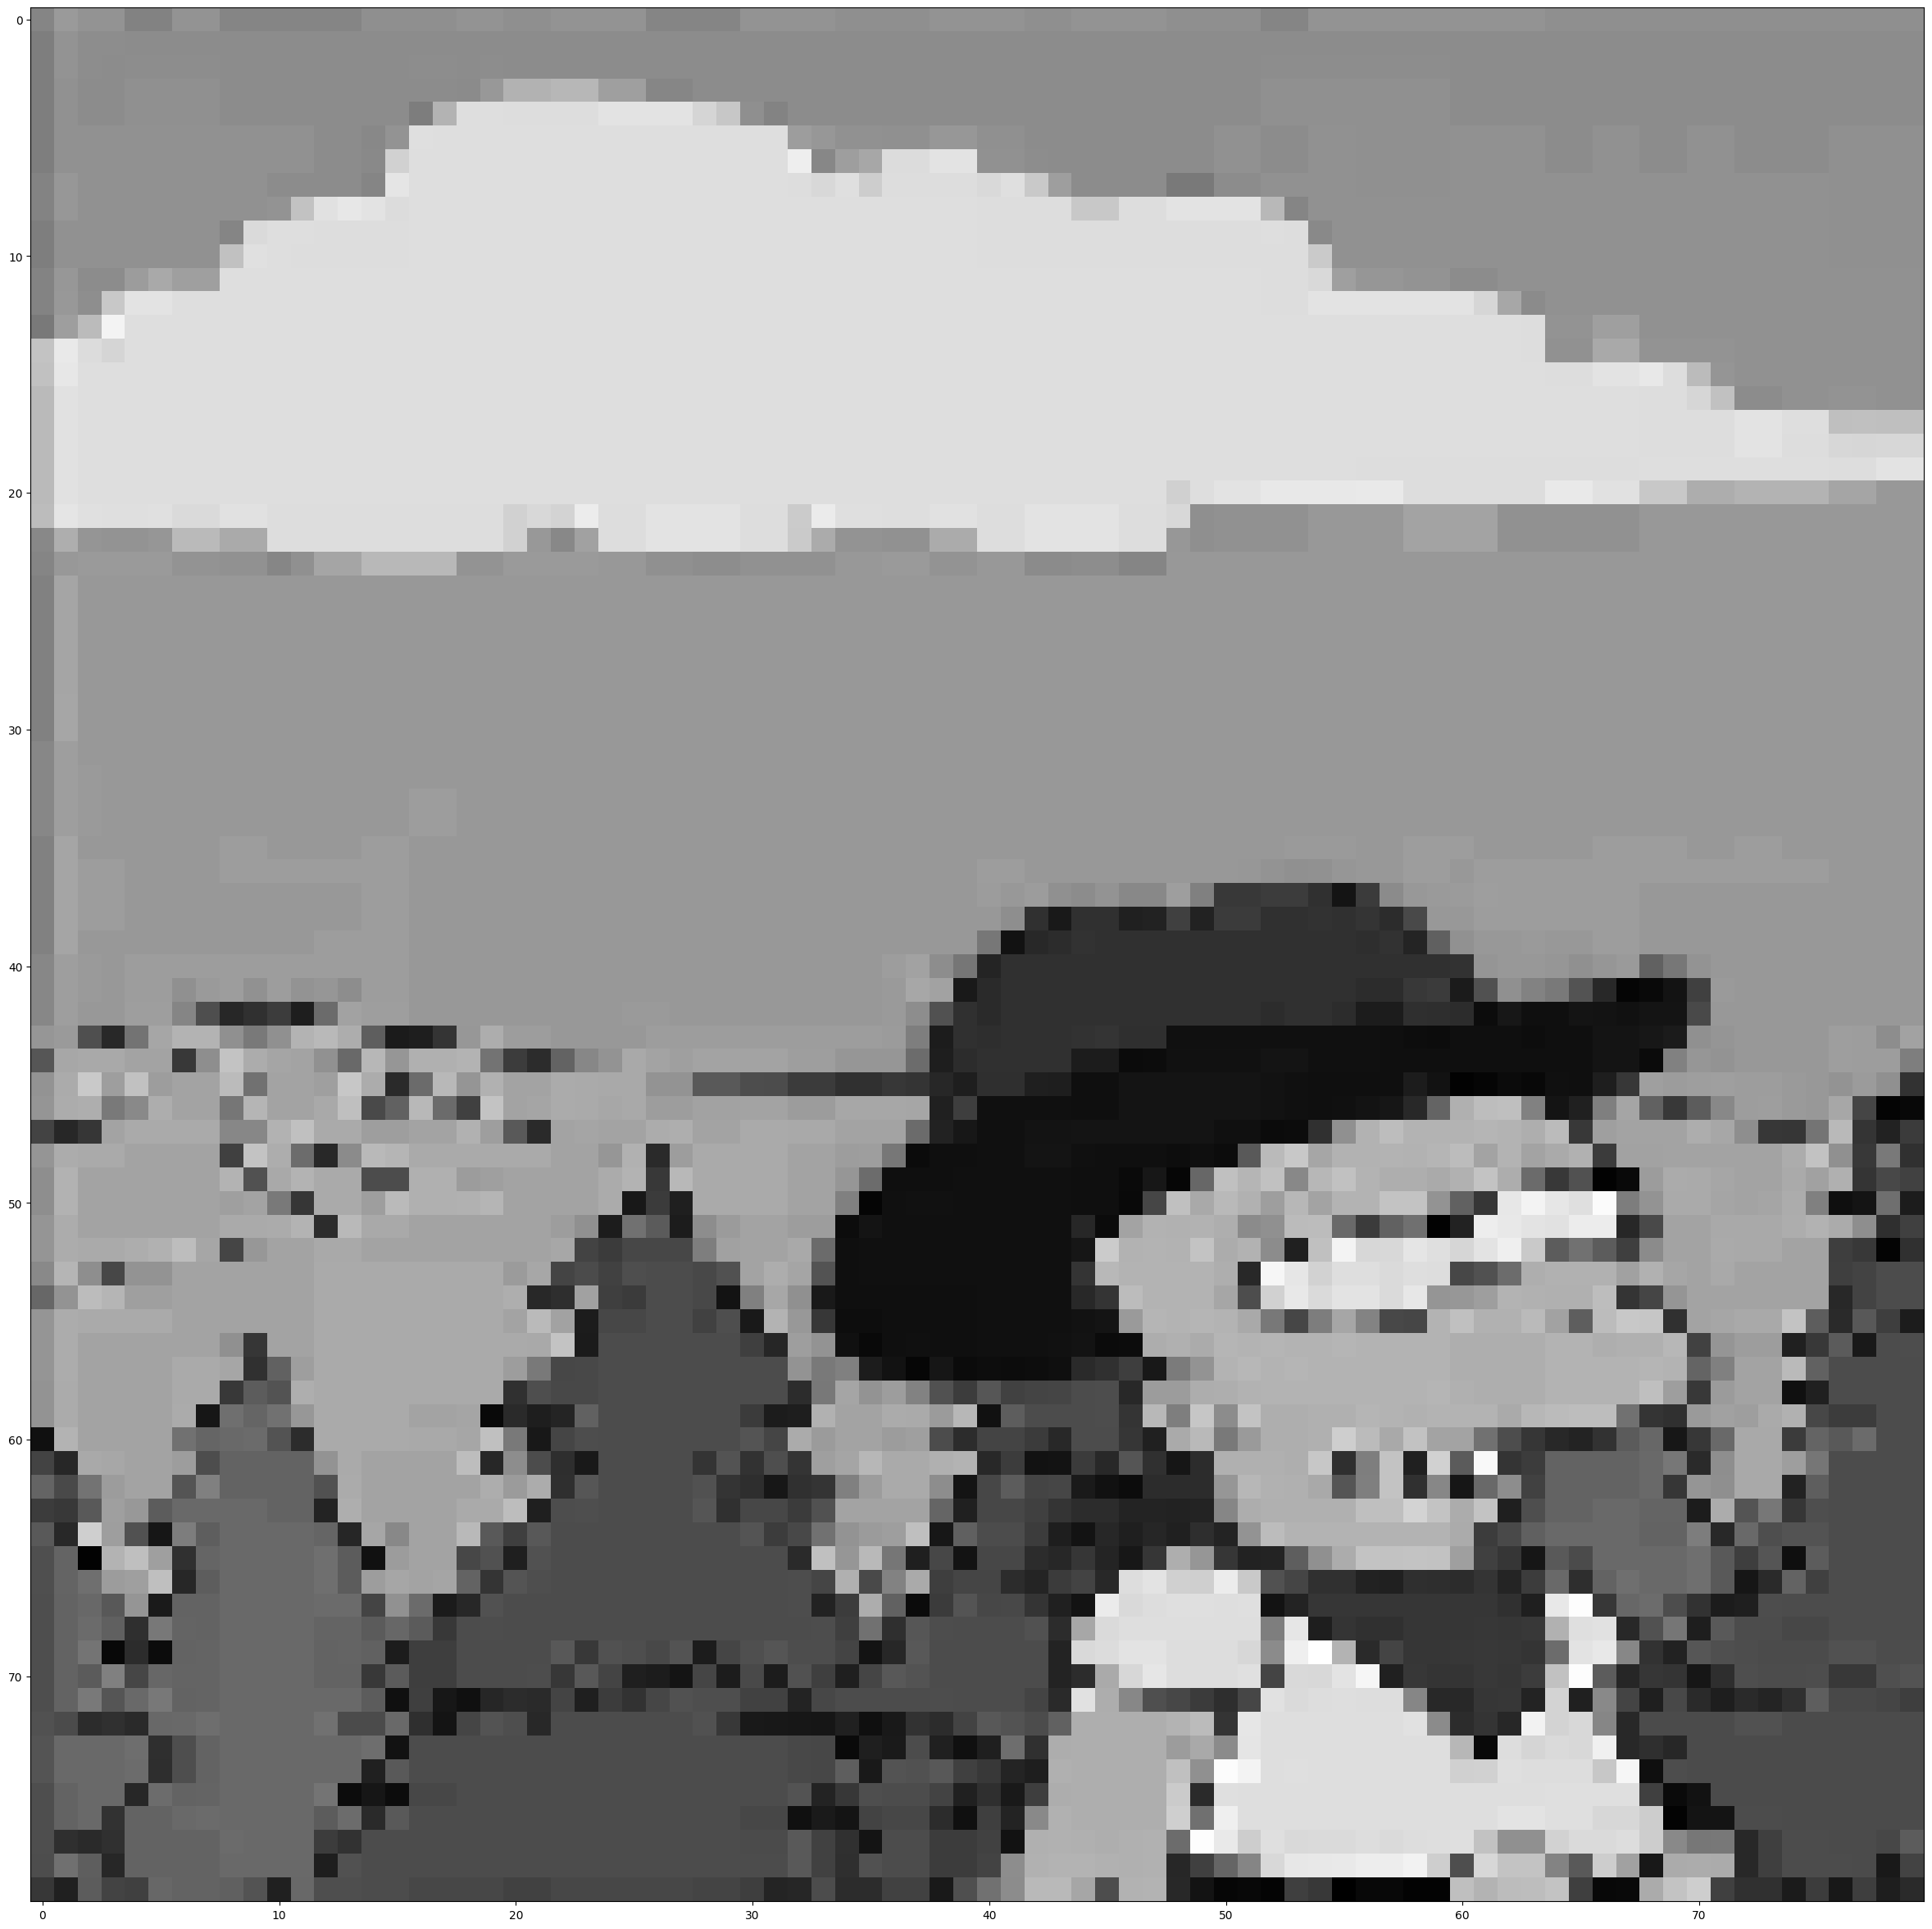

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 30))
plt.imshow(train[0][0], cmap= 'gray')
plt.show()

In [30]:
featureSet, labels = caer.sep_train(train, IMG_SIZE= IMAGE_SIZE)

In [33]:
from tensorflow.keras.utils import to_categorical
# Normalize the features ---> (0,1)
featureSet = caer.normalize(featureSet)
labels = to_categorical(labels, len(characters))

In [37]:
x_train, x_val, y_train, y_val = caer.train_val_split(featureSet, labels, val_ratio=0.2)

In [39]:
del train
del featureSet
del labels
gc.collect()

44

In [41]:
import math
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler

# 1. إعدادات الحجم والـ Hyperparameters
BATCH_SIZE = 32
EPOCHS = 10
# (تأكد أن المتغيرات دي معرفة عندك مسبقاً بناءً على أبعاد صورك)
# IMG_SIZE = (64, 64) 
# channels = 3
# num_classes = len(characters)

# 2. توليد وتجهيز البيانات بديل (canaro.generators.imageDataGenerator)
# المولد القياسي يقوم بعمل rescale للصور بين 0 و 1
datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE)

# 3. بناء الشبكة وتجميعها بديل (canaro.models.createSimpsonsModel)
def build_simpsons_model(img_size, channels, output_dims):
    model = Sequential([
        # الطبقة الأولى لقراءة الصور
        Conv2D(32, (3, 3), activation='relu', input_shape=(img_size[0], img_size[1], channels)),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        # تحويل البيانات إلى متجه أحادي
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5), # لتقليل الـ Overfitting
        
        # طبقة المخرجات (تستخدم sigmoid بناءً على اختيار الكود الأصلي لـ binary_crossentropy)
        Dense(output_dims, activation='sigmoid') 
    ])
    return model

# إنشاء النموذج
model = build_simpsons_model(IMAGE_SIZE, channels, len(characters))

# تجميع النموذج بنفس الإعدادات (SGD Optimizer مع Nesterov)
opt = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# 4. دالة جدولة معدل التعلم بديل (canaro.lr_schedule)
# هذه دالة تقليص كلاسيكية تقلل معدل التعلم كل فترة
def custom_lr_schedule(epoch):
    initial_lr = 0.001
    drop = 0.5
    epochs_drop = 5.0
    lr = initial_lr * math.pow(drop, math.floor((1 + epoch) / epochs_drop))
    return lr

callbacks_list = [LearningRateScheduler(custom_lr_schedule)]

# 5. بدء التدريب الفعلي (model.fit)
training = model.fit(
    train_gen,
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    validation_steps=len(y_val) // BATCH_SIZE,
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782221145.199048      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782221145.205286      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1782221147.560338    1220 service.cc:152] XLA service 0x7a9c2400a180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782221147.560385    1220 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782221147.560399    1220 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782221147.858305    1220 cuda_dnn.cc:529] Loaded cuDNN version 91002


 23/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0605 - loss: 0.6921

I0000 00:00:1782221151.172434    1220 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


345/345 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.0881 - loss: 0.5182 - val_accuracy: 0.1635 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 2/10
  1/345 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1250 - loss: 0.3498

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.1250 - loss: 0.3498 - val_accuracy: 0.1635 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1170 - loss: 0.3389 - val_accuracy: 0.1635 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.1875 - loss: 0.3291 - val_accuracy: 0.1635 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1160 - loss: 0.3373 - val_accuracy: 0.1635 - val_loss: 0.3385 - learning_rate: 5.0000e-04
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.0938 - loss: 0.3417 - val_accuracy: 0.1635 - val_loss: 0.3385 - learning_rate: 5.0000e-04
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1254 - loss: 0.3355 - val_accuracy: 0.1635 - val_loss: 0.3383 - learning_rate: 5.0000e-04
Epoch 8/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.1875 - loss: 

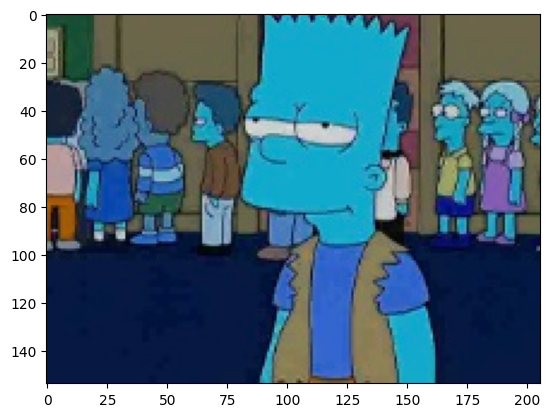

In [57]:
test_path = r'/kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset/bart_simpson_19.jpg'
img = cv.imread(test_path)

plt.imshow(img)
plt.show()

In [58]:
def prepare(img):
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.resize(img, IMAGE_SIZE)
    img = caer.reshape(img, IMAGE_SIZE, 1)
    return img

In [59]:
print("هل الملف موجود؟ :", os.path.exists(test_path))

هل الملف موجود؟ : True


In [60]:
predections = model.predict(prepare(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [61]:
predections

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [62]:
print(characters[np.argmax(predections[0])])

homer_simpson
